# 05 — Paper figures: word clouds & aspect radar

Two visualisations named explicitly in the task description, plus a qualitative validation of the aspect lexicon:

1. **Word clouds of the most discriminative terms per sentiment class** (task point 2, alongside the log-odds analysis in `01_eda`).
2. **Radar charts of aspect sentiment and mention rate across the two categories** (task point 4).
3. A **sample of aspect-assigned sentences** for qualitative inspection of lexicon precision (RQ2 has no gold labels, so this supports the limitations discussion).

All inputs are the cached artefacts from notebooks 02-04, so this notebook runs in a few seconds.

In [1]:
import sys
from pathlib import Path
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
sys.path.append(str(PROJECT_ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 150, 'savefig.bbox': 'tight'})
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'
NAVY, BLUE, ORANGE, GREY = '#1E3A6E', '#5B8DBF', '#D97757', '#BCC4CF'

## 1. Discriminative-term word clouds

The clouds are built from a **weighted log-odds ratio with an informative Dirichlet prior** (Monroe, Colaresi & Quinn, 2008) between positive and negative reviews — the same principle as the log-odds bar chart in the EDA, but rendered as the word clouds the task asks for. Word size is proportional to the z-scored log-odds, so size reflects how *discriminative* a term is, not merely how frequent.

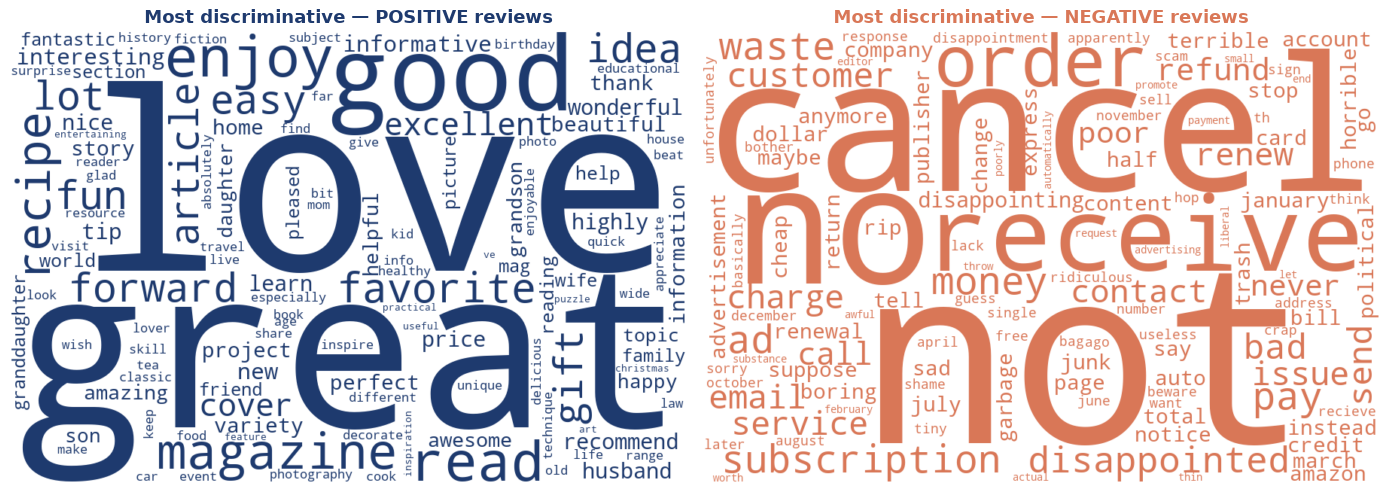

Top positive: ['love', 'great', 'good', 'enjoy', 'read', 'magazine', 'recipe', 'favorite', 'idea', 'lot']
Top negative: ['not', 'cancel', 'no', 'receive', 'order', 'subscription', 'pay', 'money', 'ad', 'waste']


In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

df = pd.read_parquet(PROC_DIR / 'reviews_clean.parquet')
d = df[(df['clean_text'].str.len() > 0) & (df['sentiment_binary'].notna())]

vec = CountVectorizer(min_df=20)
X = vec.fit_transform(d['clean_text'])
vocab = np.array(vec.get_feature_names_out())
is_pos = (d['sentiment_binary'] == 'positive').values

cnt_pos = np.asarray(X[is_pos].sum(axis=0)).ravel().astype(float)
cnt_neg = np.asarray(X[~is_pos].sum(axis=0)).ravel().astype(float)

# weighted log-odds with informative Dirichlet prior (alpha_w proportional to corpus freq)
a0 = 1000.0
total = cnt_pos + cnt_neg
alpha = a0 * total / total.sum()
n_pos, n_neg, aA = cnt_pos.sum(), cnt_neg.sum(), alpha.sum()
delta = (np.log((cnt_pos + alpha) / (n_pos + aA - cnt_pos - alpha))
         - np.log((cnt_neg + alpha) / (n_neg + aA - cnt_neg - alpha)))
var = 1.0 / (cnt_pos + alpha) + 1.0 / (cnt_neg + alpha)
z = delta / np.sqrt(var)

pos_freq = {w: zz for w, zz in zip(vocab, z) if zz > 0}
neg_freq = {w: -zz for w, zz in zip(vocab, z) if zz < 0}
top_pos = dict(sorted(pos_freq.items(), key=lambda kv: kv[1], reverse=True)[:120])
top_neg = dict(sorted(neg_freq.items(), key=lambda kv: kv[1], reverse=True)[:120])

def cloud(freqs, color):
    # random_state fixes the word-placement layout so the figure is reproducible.
    return WordCloud(width=900, height=600, background_color='white', prefer_horizontal=0.95,
                     random_state=42, colormap=None, color_func=lambda *a, **k: color).generate_from_frequencies(freqs)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(cloud(top_pos, NAVY), interpolation='bilinear'); ax[0].axis('off')
ax[0].set_title('Most discriminative — POSITIVE reviews', fontweight='bold', color=NAVY, fontsize=13)
ax[1].imshow(cloud(top_neg, ORANGE), interpolation='bilinear'); ax[1].axis('off')
ax[1].set_title('Most discriminative — NEGATIVE reviews', fontweight='bold', color=ORANGE, fontsize=13)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'wordcloud_sentiment.png'); plt.show()
print('Top positive:', list(top_pos)[:10])
print('Top negative:', list(top_neg)[:10])

**Reading.** The negative cloud is dominated by *cancel / cancelled / subscription / refund / ad / advertisement* — a billing-and-advertising cluster — exactly mirroring the strongest negative Logistic-Regression coefficients in RQ1 and foreshadowing the billing finding in RQ2. The positive cloud is generic affect (*love, great, enjoy, wonderful*). The clouds visualise the same signal as the log-odds bar chart in a form that is quick to read.

## 2. Aspect sentiment & mention rate as radar charts

The radar (spider) chart is the task-requested view of *average sentiment per aspect*, here drawn for both categories so their profiles can be compared at a glance. A second radar shows how often each aspect is mentioned.

**Axis fix.** An earlier version of this chart used a fixed radial range of `(0.10, 0.40)` for the sentiment radar, even though several aspects (billing, customer service) have **negative** mean compound values. A polar axis cannot display values below its lower limit — they get silently clipped to the floor, making genuinely different sentiment levels look visually identical. The sentiment radar below instead: (1) computes the radial range dynamically from the actual data (with a small margin) so negative values are never clipped, and (2) plots the VADER compound transformed via `(compound + 1) / 2` onto `[0, 1]` for the polar geometry, while the **radial tick labels show the original compound scale** (`-1` to `1`), so the chart remains directly readable in VADER's native units. This is a geometry-only transform; no underlying numbers change.

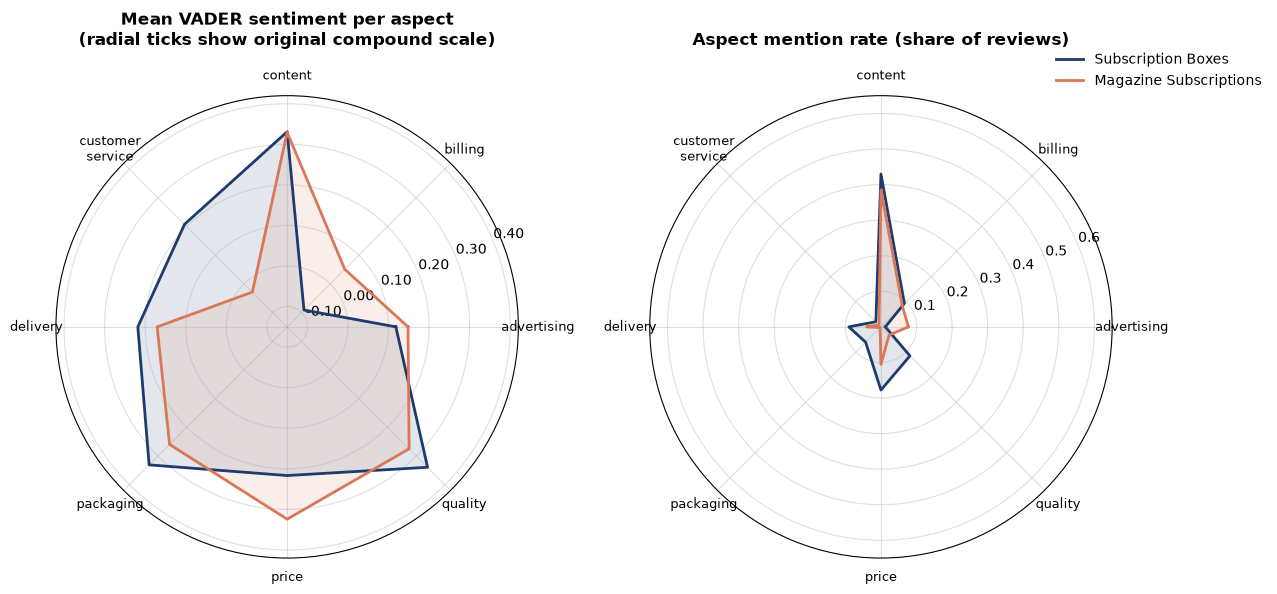

In [3]:
agg = pd.read_csv(TABLES_DIR / 'rq2_aspect_summary.csv')
CAT_LABEL = {'Subscription_Boxes': 'Subscription Boxes', 'Magazine_Subscriptions': 'Magazine Subscriptions'}
aspects = sorted(agg['aspect'].unique())
ang = np.linspace(0, 2 * np.pi, len(aspects), endpoint=False).tolist()
ang += ang[:1]  # close loop

def compound_to_unit(c):
    """Map VADER compound [-1, 1] -> [0, 1] for polar geometry only; the radial
    axis is re-labelled back to the original compound scale below."""
    return (c + 1) / 2

def radar(ax, metric, title, rlim, transform=None, tick_values=None):
    for cat, color in [('Subscription_Boxes', NAVY), ('Magazine_Subscriptions', ORANGE)]:
        sub = agg[agg['category'] == cat].set_index('aspect').reindex(aspects)
        vals = sub[metric].tolist()
        if transform:
            vals = [transform(v) for v in vals]
        vals += vals[:1]
        ax.plot(ang, vals, color=color, lw=2, label=CAT_LABEL[cat])
        ax.fill(ang, vals, color=color, alpha=0.12)
    ax.set_xticks(ang[:-1]); ax.set_xticklabels([a.replace('_', '\n') for a in aspects], fontsize=9)
    ax.set_ylim(*rlim); ax.set_title(title, fontweight='bold', pad=18)
    ax.grid(alpha=0.4)
    if tick_values is not None:
        positions = [transform(v) for v in tick_values] if transform else tick_values
        ax.set_rgrids(positions, labels=[f'{v:.2f}' for v in tick_values])

# Dynamic radial range for sentiment, computed from the actual data (with a
# small margin) so negative values (billing, customer service) are never
# clipped, unlike the earlier fixed (0.10, 0.40) range.
sent_min, sent_max = agg['mean_compound'].min(), agg['mean_compound'].max()
sent_lo = np.floor(sent_min * 10) / 10
sent_hi = np.ceil(sent_max * 10) / 10
tick_values = np.round(np.arange(sent_lo, sent_hi + 1e-9, 0.1), 2)
sent_rlim = (compound_to_unit(sent_lo - 0.05), compound_to_unit(sent_hi + 0.02))

fig, ax = plt.subplots(1, 2, figsize=(13, 6), subplot_kw=dict(polar=True))
radar(ax[0], 'mean_compound', 'Mean VADER sentiment per aspect\n(radial ticks show original compound scale)',
      sent_rlim, transform=compound_to_unit, tick_values=tick_values)
radar(ax[1], 'mention_rate', 'Aspect mention rate (share of reviews)', (0.0, 0.65))
ax[1].legend(loc='upper right', bbox_to_anchor=(1.35, 1.12), frameon=False)
plt.tight_layout(); plt.savefig(FIGURES_DIR / 'rq2_aspect_radar.png'); plt.show()

**Reading.** With the dynamic, non-clipping radial range, both sentiment polygons now visibly dip at **billing** (the only aspect with a negative mean for Subscription Boxes, and the weakest high-coverage aspect for Magazine Subscriptions — see notebook 04, Section 4a for the formal "high coverage" definition), instead of that dip being hidden by a fixed axis floor. The radial tick labels show the original VADER compound scale (`-1` to `1`), so the chart is directly readable in VADER's native units despite the `(compound + 1) / 2` geometry transform used to draw it. The mention-rate radar no longer treats generic product labels as aspects; after removing `box`, `magazine`, and `subscription` as triggers, *content* is the largest discussion theme and *advertising* appears mainly as a magazine-side aspect.


## 3. Illustrative qualitative spot-check of the aspect lexicon

RQ2 is unsupervised, so there are no gold aspect labels to score against. **This is not an independent or blinded manual annotation** — the deterministic sample of 80 aspect-assigned sentences below is inspected and judged by the author of this notebook, with the judgement encoded directly as code literals (`manual_is_correct` defaults to `True`, with three explicit overrides written after reading the sample). There is no second annotator, no inter-annotator agreement, and no separately stored annotation file independent of this notebook's source code. It is reported as an **illustrative qualitative spot-check**, not as a validated precision estimate or a gold-standard evaluation — the resulting "77/80" count should be read with that caveat every time it is cited (including in the paper). The sample itself is deterministic, so the same rows can be reproduced exactly.


In [4]:
from src import aspect_extraction as ax_mod
rows = []
TARGET_PER_ASPECT = 10
sample_pool = df[df['text'].str.len() > 0].sample(min(20000, len(df)), random_state=0)
per_aspect = {a: [] for a in ax_mod.DEFAULT_ASPECT_KEYWORDS}
for txt in sample_pool['text']:
    for s in ax_mod.split_into_sentences(txt):
        s_low = s.lower()
        for a, kws in ax_mod.DEFAULT_ASPECT_KEYWORDS.items():
            if len(per_aspect[a]) < TARGET_PER_ASPECT and ax_mod.sentence_mentions_aspect(s_low, kws):
                matched = ';'.join(ax_mod.matched_aspect_keywords(s_low, kws))
                per_aspect[a].append((s.strip()[:220], matched, round(ax_mod.vader_compound(s), 3), ax_mod.vader_label(ax_mod.vader_compound(s))))
    if all(len(v) >= TARGET_PER_ASPECT for v in per_aspect.values()):
        break
for a, items in per_aspect.items():
    for sent, matched, comp, lab in items:
        rows.append({'aspect': a, 'matched_keywords': matched, 'example_sentence': sent,
                     'vader_compound': comp, 'vader_label': lab})
val = pd.DataFrame(rows)

# Manual audit after reading the deterministic sample. "Correct" means the
# sentence genuinely discusses the assigned aspect; it does not judge VADER's
# sentiment score, which is a separate limitation.
note_by_aspect = {
    'advertising': 'advertising or ads discussed',
    'billing': 'billing, charge, renewal, refund or cancellation discussed',
    'content': 'product/editorial content discussed',
    'customer_service': 'specific customer-service/support interaction discussed',
    'delivery': 'delivery, shipping or arrival discussed',
    'packaging': 'package or packaging discussed',
    'price': 'price, cost, fee or money discussed',
    'quality': 'quality, construction or composition discussed',
}
val['sample_no_within_aspect'] = val.groupby('aspect').cumcount()
val['manual_is_correct'] = True
val['manual_note'] = val['aspect'].map(note_by_aspect).fillna('plausible aspect assignment')

# Manual corrections from the illustrative audit. These matches are lexical hits,
# but the sentence meaning does not discuss the assigned aspect under the coding
# rule used in the paper.
manual_overrides = {
    ('advertising', 6): (False, 'false positive: "as advertised" means as stated, not advertising content'),
    ('content', 6): (False, 'false positive: magazine issue is mentioned only in a delivery context'),
    ('packaging', 6): (False, 'false positive: renewal mailer is not product packaging'),
}
for (aspect, sample_no), (is_correct, note) in manual_overrides.items():
    mask = (val['aspect'] == aspect) & (val['sample_no_within_aspect'] == sample_no)
    val.loc[mask, 'manual_is_correct'] = is_correct
    val.loc[mask, 'manual_note'] = note

val.to_csv(TABLES_DIR / 'rq2_aspect_validation_sample.csv', index=False)
summary = val.groupby('aspect')['manual_is_correct'].agg(['sum', 'size', 'mean']).rename(
    columns={'sum': 'correct', 'size': 'inspected', 'mean': 'estimated_precision'}).round(3)
summary.loc['overall'] = [int(val['manual_is_correct'].sum()), len(val), round(val['manual_is_correct'].mean(), 3)]
summary.to_csv(TABLES_DIR / 'rq2_manual_validation_summary.csv')
print(summary)
val.head(25)



                  correct  inspected  estimated_precision
aspect                                                   
advertising           9.0       10.0                0.900
billing              10.0       10.0                1.000
content               9.0       10.0                0.900
customer_service     10.0       10.0                1.000
delivery             10.0       10.0                1.000
packaging             9.0       10.0                0.900
price                10.0       10.0                1.000
quality              10.0       10.0                1.000
overall              77.0       80.0                0.962


,aspect,matched_keywords,example_sentence,vader_compound,vader_label,sample_no_within_aspect,manual_is_correct,manual_note
0,delivery,arrive,"It took a while to arrive but once it did, he ...",0.000,neutral,0,True,"delivery, shipping or arrival discussed"
1,delivery,arrived,These are packed very well and have arrived wi...,0.615,positive,1,True,"delivery, shipping or arrival discussed"
2,delivery,arrived,"Did not receive all issues, & the one I did ge...",0.000,neutral,2,True,"delivery, shipping or arrival discussed"
3,delivery,arrived,And it auto-renewed 3 months later (as adverti...,0.000,neutral,3,True,"delivery, shipping or arrival discussed"
4,delivery,arrive,My only negative comment as that I ordered thi...,-0.572,negative,4,True,"delivery, shipping or arrival discussed"
5,delivery,delivery,"However, I’m disappointed in the delivery and ...",-0.477,negative,5,True,"delivery, shipping or arrival discussed"
6,delivery,arrived,My first issue (the April issue) finally arriv...,0.000,neutral,6,True,"delivery, shipping or arrival discussed"
7,delivery,delivered,"I know the day they get delivered, when I come...",-0.340,negative,7,True,"delivery, shipping or arrival discussed"
8,delivery,arrived,It arrived exactly as expected.,0.000,neutral,8,True,"delivery, shipping or arrival discussed"
9,delivery,arrive,The plants that arrive are in wonderful condit...,0.670,positive,9,True,"delivery, shipping or arrival discussed"


**Reading.** The spot-check verifies whether the keyword hit genuinely refers to the assigned aspect, judged by the notebook's author rather than an independent annotator (see the caveat above). After removing broad product identifiers (`box`, `magazine`, `subscription`) and broad customer-service terms (`service`, `email`, `phone`, `support`) from the detection lexicon, the deterministic sample is designed as a small illustrative plausibility check rather than a full gold-standard evaluation. The remaining limitation is granularity: some sentences still mention multiple aspects and therefore receive one shared VADER score (see notebook 04, Section 2a for the clause-level sensitivity analysis that probes exactly this limitation).
